### Load Data

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

def generate_data(n, r, inv=False):
    x = list(range(-n//2, n//2))
    if inv:
        y = [n-random.randint(i-r, i+r) for i in x]
    else:
        y = [random.randint(i-r, i+r) for i in x]
    plt.scatter(x, y)
    plt.grid()
    plt.show()
    return np.array(x), np.array(y)

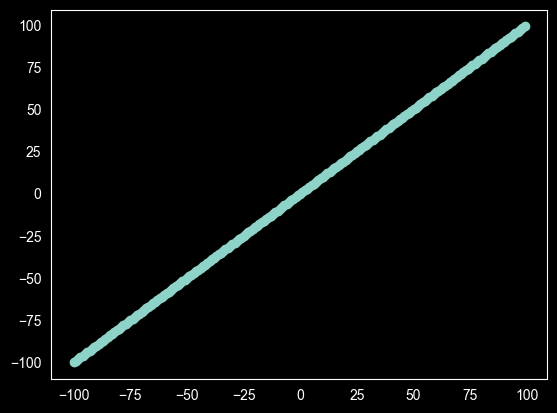

In [2]:
# Data 1
n = 200
r = 0
x1, y1 = generate_data(n, r)

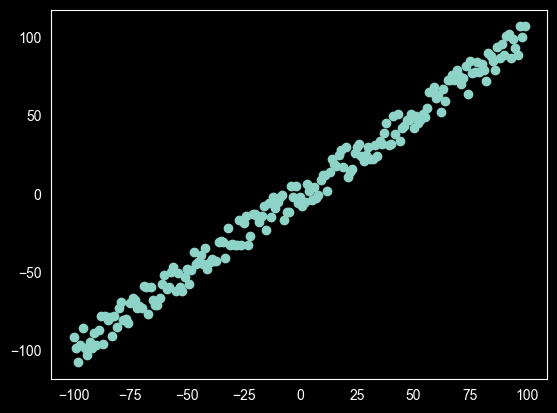

In [3]:
# Data 2
n = 200
r = 10
x2, y2 = generate_data(n, r)

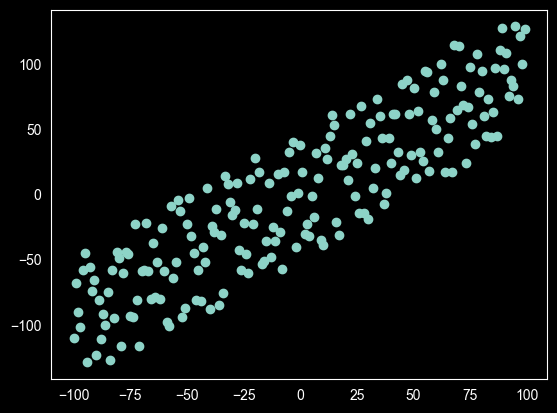

In [4]:
# Data 3
n = 200
r = 50
x3, y3 = generate_data(n, r)

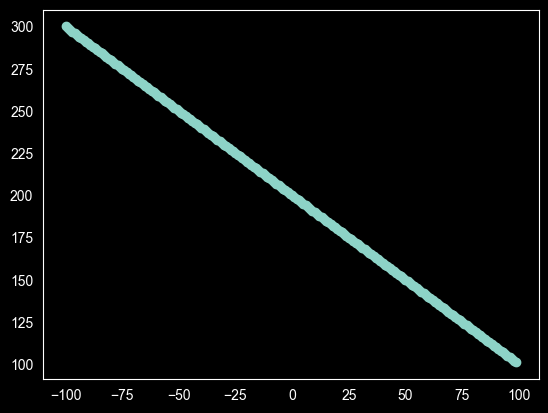

In [5]:
# Data 4
n = 200
r = 0
x4, y4 = generate_data(n, r, inv=True)

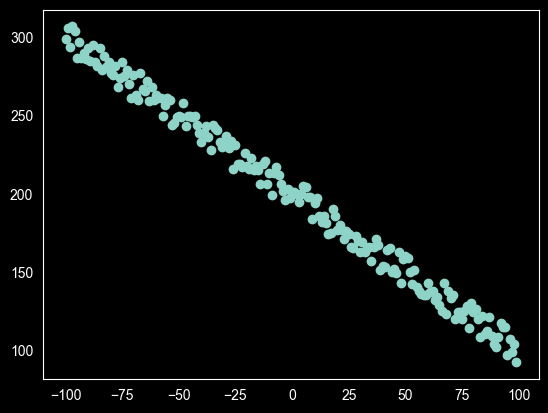

In [6]:
# Data 5
n = 200
r = 10
x5, y5 = generate_data(n, r, inv=True)

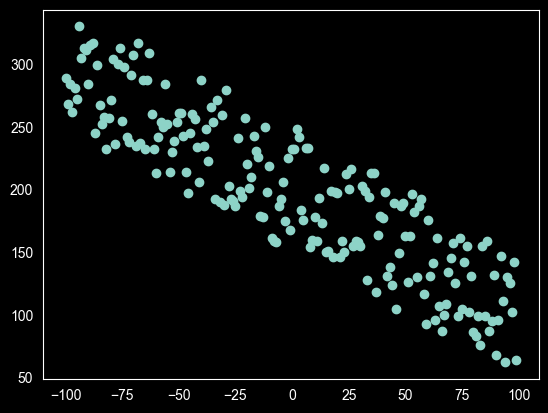

In [7]:
# Data 6
n = 200
r = 50
x6, y6 = generate_data(n, r, inv=True)

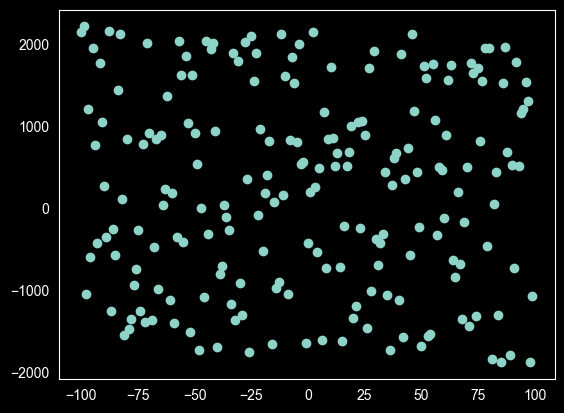

In [70]:
# Data 7
n = 200
r = 2000
x7, y7 = generate_data(n, r, inv=True)

### Metrics

In [9]:
def predict(x, m, c):
    return m*x + c

In [10]:
def mse(y, y_pred):
    n = len(y)
    sse = 0
    error = y_pred - y
    se = error**2
    sse = sum(se)
    mse = sse/n
    try:
        return round(mse, 4)
    except Exception:
        return mse

In [11]:
def r2(y, y_pred):
    y_mean = np.mean(y)
    try:
        return round(1 - sum((y-y_pred)**2)/sum((y-y_mean)**2), 4)
    except Exception:
        return 1 - sum((y-y_pred)**2)/sum((y-y_mean)**2)


### Solve by Normal Equation

In [57]:
def solve_by_norm_eq(x, y, lmbda=300000):
    x_b = np.array([[1, i] for i in x])
    I = np.eye(2)
    I[0, 0] = 0
    c, m = np.linalg.inv(x_b.T @ x_b + lmbda * I) @ x_b.T @ y
    y_pred = predict(x, m, c)
    MSE = mse(y, y_pred)
    R2 = r2(y, y_pred)
    print(f"Slope :", round(m, 4), "  y-Intercept :", round(c, 4), "  MSE :", MSE, "  R2 :", R2)
    plt.scatter(x, y)
    plt.plot(x, [m*i+c for i in x], "r")
    plt.grid()
    plt.show()

Slope : 0.6896   y-Intercept : -0.1552   MSE : 321.0494   R2 : 0.9037


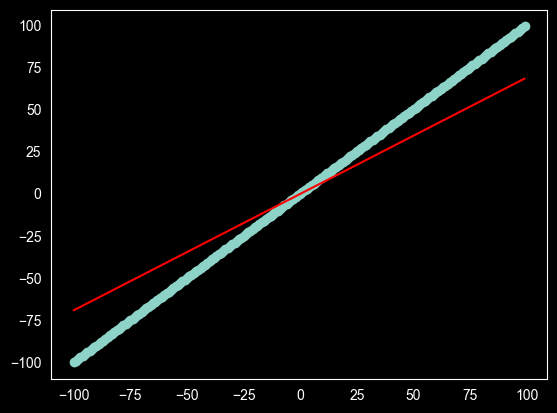

In [58]:
# Solve for Data 1
solve_by_norm_eq(x1, y1)

Slope : 0.694   y-Intercept : 0.057   MSE : 365.1973   R2 : 0.8931


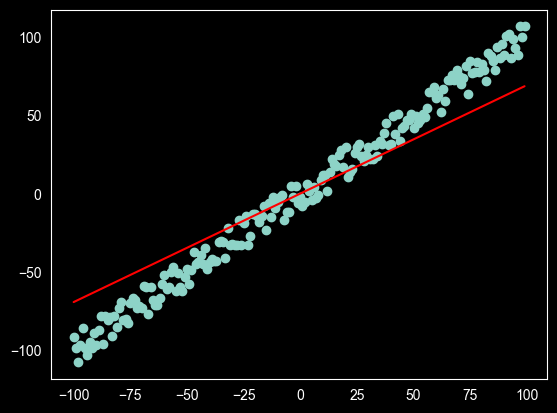

In [59]:
# Solve for Data 2
solve_by_norm_eq(x2, y2)

Slope : 0.6615   y-Intercept : 0.2258   MSE : 1135.7736   R2 : 0.7093


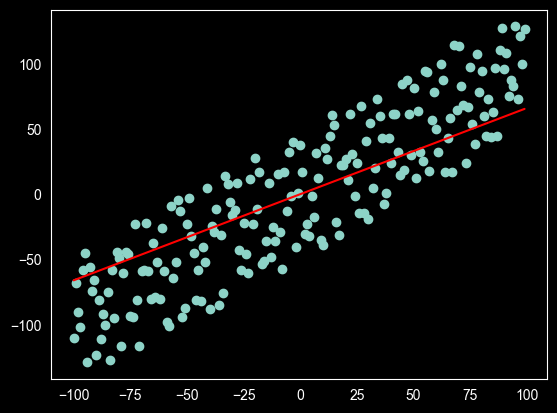

In [60]:
# Solve for Data 3
solve_by_norm_eq(x3, y3)

Slope : -0.6896   y-Intercept : 200.1552   MSE : 321.0494   R2 : 0.9037


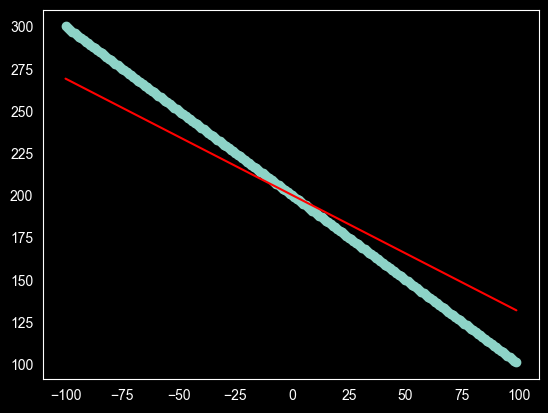

In [61]:
# Solve for Data 4
solve_by_norm_eq(x4, y4)

Slope : -0.6956   y-Intercept : 200.2522   MSE : 360.0985   R2 : 0.8948


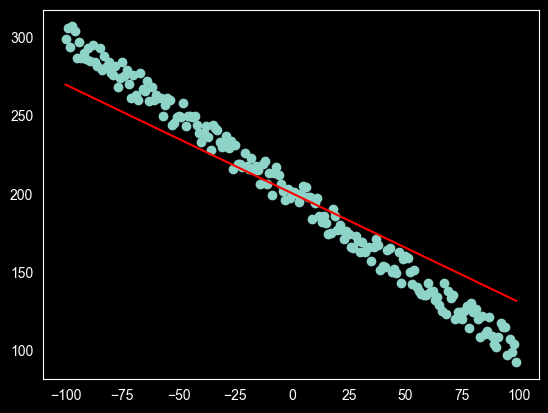

In [62]:
# Solve for Data 5
solve_by_norm_eq(x5, y5)

Slope : -0.6654   y-Intercept : 197.8523   MSE : 1155.741   R2 : 0.7081


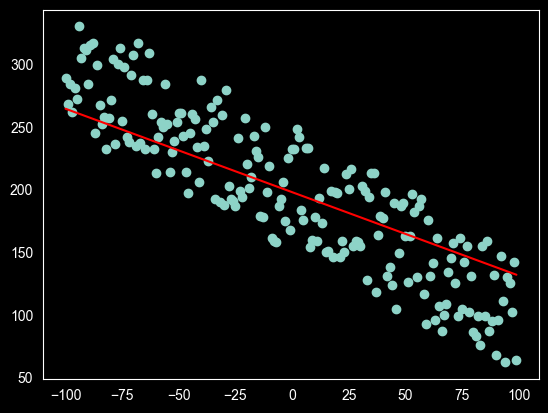

In [65]:
# Solve for Data 6
solve_by_norm_eq(x6, y6)

Slope : -0.9591   y-Intercept : 289.3704   MSE : 1291817.5044   R2 : 0.0045


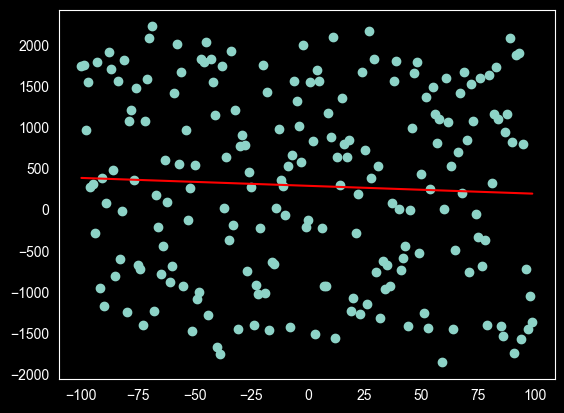

In [66]:
# Solve for Data 7
solve_by_norm_eq(x7, y7)

### Solve by Gradient Descent

In [75]:
def solve_by_grad_descent(x, y, n_epochs=300, eta=0.1, lmbda=1):
    x_scaled = (x - x.mean()) / x.std()
    y_scaled = (y - y.mean()) / y.std()
    x_b = np.array([[1, i] for i in x_scaled])
    theta = np.array([0, 0]).reshape(-1, 1)
    m = len(x_b)
    y_scaled = y_scaled.reshape(-1, 1)
    for epoch in range(n_epochs):
        gradients = 2 / m * x_b.T @ (x_b @ theta - y_scaled)
        ridge_gradient = 2 * lmbda * theta
        ridge_gradient[0] = 0
        gradients += ridge_gradient
        theta = theta - eta * gradients
    c_scaled = theta[0][0]
    m_scaled = theta[1][0]
    m = m_scaled * y.std() / x.std()
    c = (c_scaled * y.std() + y.mean() - m * x.mean())
    y_pred = predict(x, m, c)
    MSE = round(mse(y, y_pred.reshape(-1, 1))[0], 4)
    R2 = round(r2(y, y_pred.reshape(-1, 1))[0], 4)
    print(
        f"Slope : {round(m, 4)}"
        f"  y-Intercept : {round(c, 4)}"
        f"  MSE : {MSE}"
        f"  R2 : {R2}"
    )
    plt.scatter(x, y)
    plt.plot(x, [m * i + c for i in x], "r")
    plt.grid()
    plt.show()

Slope : 0.5  y-Intercept : -0.25  MSE : 10733.5625  R2 : -2.2201


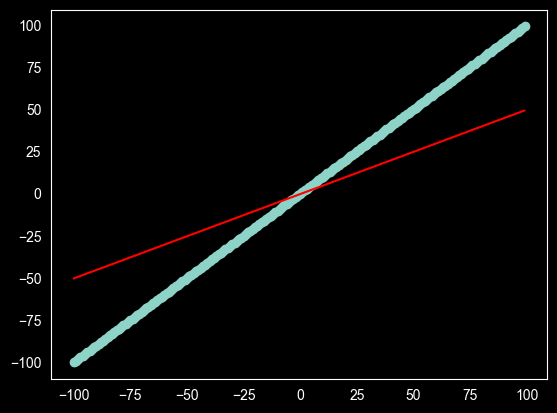

In [78]:
# Solve for Data 1
solve_by_grad_descent(x1, y1)

Slope : 0.5032  y-Intercept : -0.0384  MSE : 9254.6703  R2 : -1.7093


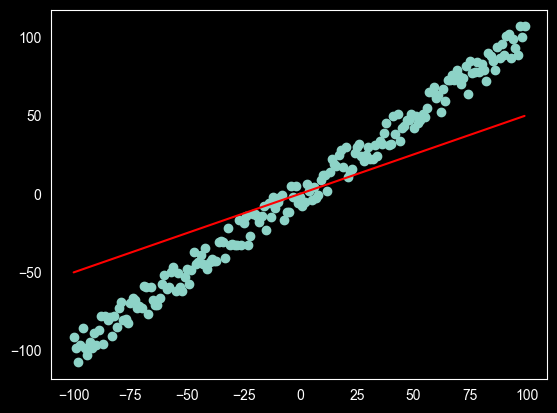

In [79]:
# Solve for Data 2
solve_by_grad_descent(x2, y2)

Slope : 0.4796  y-Intercept : 0.1348  MSE : 12843.6431  R2 : -2.2871


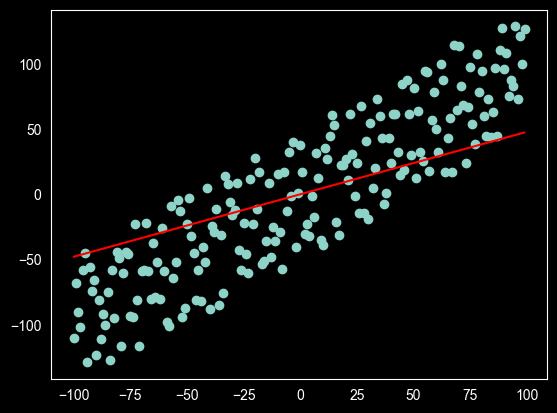

In [80]:
# Solve for Data 3
solve_by_grad_descent(x3, y3)

Slope : -0.5  y-Intercept : 200.25  MSE : 10733.5625  R2 : -2.2201


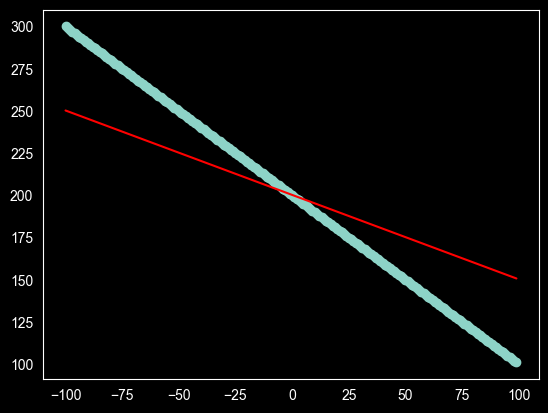

In [81]:
# Solve for Data 4
solve_by_grad_descent(x4, y4)

Slope : -0.5043  y-Intercept : 200.3479  MSE : 10530.2666  R2 : -2.0751


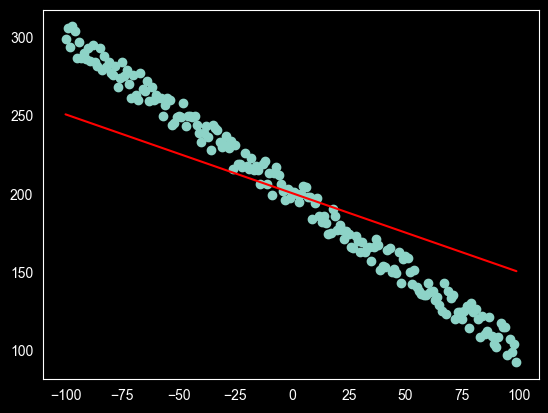

In [82]:
# Solve for Data 5
solve_by_grad_descent(x5, y5)

Slope : -0.4824  y-Intercept : 197.9438  MSE : 9023.0816  R2 : -1.2787


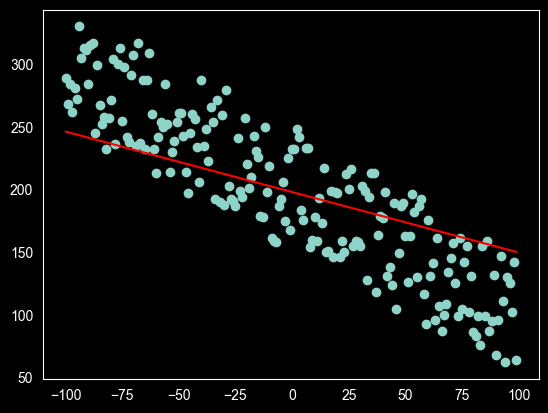

In [83]:
# Solve for Data 6
solve_by_grad_descent(x6, y6)

Slope : -0.055  y-Intercept : 239.5375  MSE : 3653593.85  R2 : -1.5142


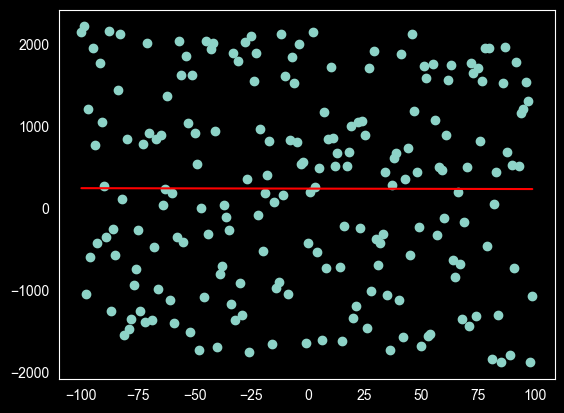

In [84]:
# Solve for Data 7
solve_by_grad_descent(x7, y7)

### Solve by SkLearn

In [42]:
from sklearn.linear_model import Ridge

def get_model(X, y):
    model = Ridge(alpha=300000)
    model.fit(X, y)
    return model.intercept_, model.coef_, model

In [43]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import add_dummy_feature

def solve_by_sklearn(x, y):
    x_b = x.reshape(-1, 1)
    c, m, model = get_model(x_b, y)
    y_pred = model.predict(x_b)
    MSE = mean_squared_error(y, y_pred)
    R2 = r2_score(y, y_pred)
    print(f"Slope :", m, "  y-Intercept :", round(c, 4), "  MSE :", MSE, "  R2 :", R2)
    plt.scatter(x, y)
    plt.plot(x, [m*i+c for i in x], "r")
    plt.grid()
    plt.show()


Slope : [0.68964982]   y-Intercept : -0.1552   MSE : 321.0494177798493   R2 : 0.9036827667352136


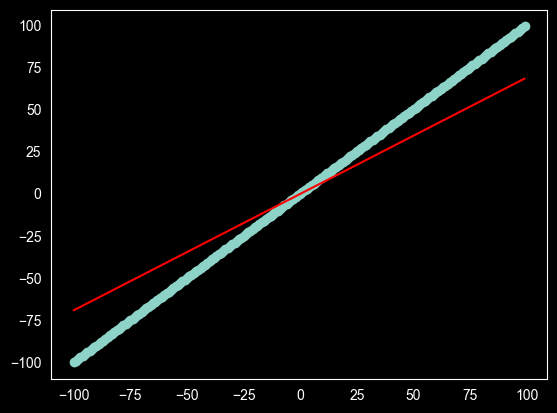

In [46]:
# Solve for Data 1
solve_by_sklearn(x1, y1)

Slope : [0.6940361]   y-Intercept : 0.057   MSE : 365.19732006926193   R2 : 0.8930869834615702


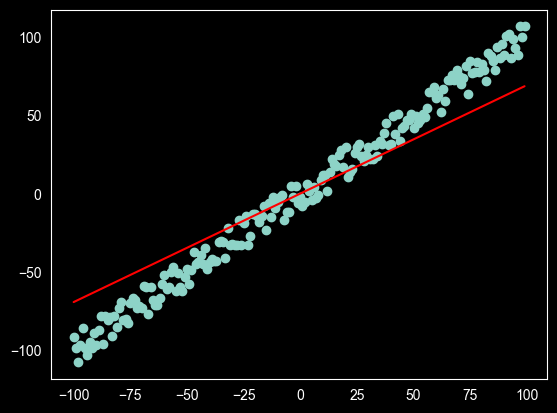

In [47]:
# Solve for Data 2
solve_by_sklearn(x2, y2)

Slope : [0.66152537]   y-Intercept : 0.2258   MSE : 1135.7736042341173   R2 : 0.709320387791401


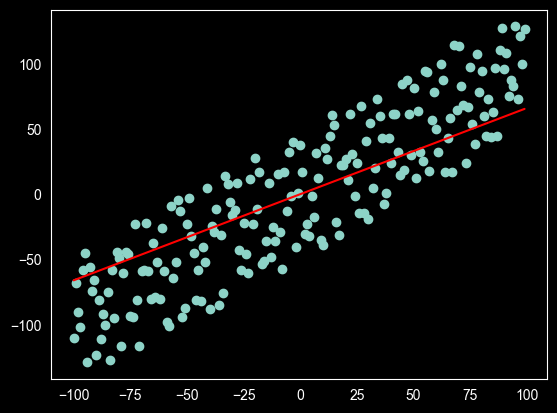

In [48]:
# Solve for Data 3
solve_by_sklearn(x3, y3)

Slope : [-0.68964982]   y-Intercept : 200.1552   MSE : 321.0494177798493   R2 : 0.9036827667352136


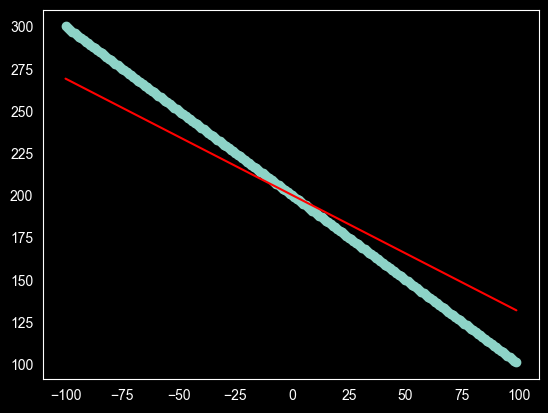

In [49]:
# Solve for Data 4
solve_by_sklearn(x4, y4)

Slope : [-0.69558061]   y-Intercept : 200.2522   MSE : 360.0985171737903   R2 : 0.8948411755952872


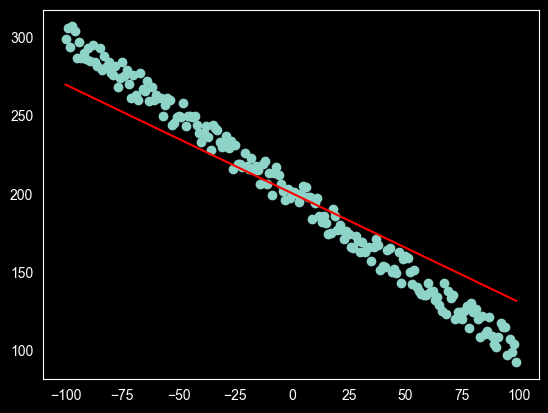

In [50]:
# Solve for Data 5
solve_by_sklearn(x5, y5)

Slope : [-0.66539027]   y-Intercept : 197.8523   MSE : 1155.741037279362   R2 : 0.7081278335555444


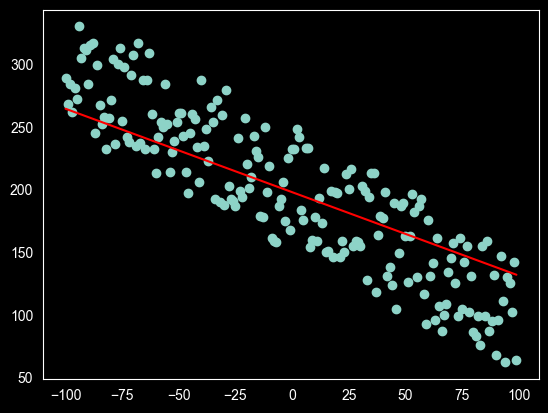

In [51]:
# Solve for Data 6
solve_by_sklearn(x6, y6)

Slope : [-0.95911964]   y-Intercept : 289.3704   MSE : 1291817.5044283352   R2 : 0.004489694548771017


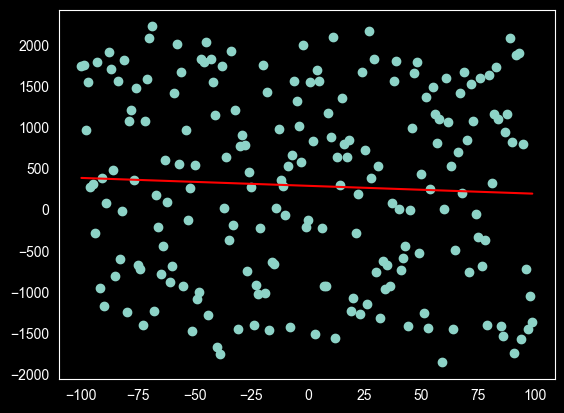

In [52]:
# Solve for Data 7
solve_by_sklearn(x7, y7)